# Notebook 07 — Hybrid M4: CNN-BiLSTM Encoder + Attention Decoder (Seq2Seq)


In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import random, time
from dataclasses import dataclass
from functools import partial
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Using device: {DEVICE} | torch {torch.__version__}")

Using device: mps | torch 2.12.0


In [2]:
@dataclass
class Config:
    data_root: Path = Path("../data/pharmacy_lk")
    train_csv: str = "splits/train.csv"; val_csv: str = "splits/val.csv"; test_csv: str = "splits/test.csv"
    img_dir: str = "images"; img_col: str = "image_filename"; label_col: str = "medicine_name"
    img_height: int = 48; img_width: int = 320

    enc_rnn_hidden: int = 256       # BiLSTM encoder hidden (matches baseline)
    enc_rnn_layers: int = 2
    dec_hidden: int = 256           # decoder GRU hidden
    emb_dim: int = 128              # character embedding for the decoder
    attn_dim: int = 256
    dropout: float = 0.2

    batch_size: int = 64
    epochs: int = 120
    lr: float = 5e-4
    warmup_epochs: int = 5
    weight_decay: float = 1e-4
    grad_clip: float = 5.0
    teacher_forcing: float = 0.5    # prob. of feeding ground-truth char during training
    early_stop_patience: int = 20
    max_decode_len: int = 30        # safety cap on generated length
    num_workers: int = 0
    ckpt_dir: Path = Path("../checkpoints/hybrid_m4")

CFG = Config()
CFG.ckpt_dir.mkdir(parents=True, exist_ok=True)

## 1. Vocabulary with special tokens
Unlike CTC (which needs only a blank), a seq2seq decoder needs **<sos>** (start), **<eos>**
(end), and **<pad>** tokens. The decoder starts from <sos> and generates until it emits <eos>.

In [3]:
class Vocab:
    PAD, SOS, EOS = 0, 1, 2
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.idx2char = {0: "<pad>", 1: "<sos>", 2: "<eos>"}
        for i, c in enumerate(chars):
            self.idx2char[i + 3] = c
        self.char2idx = {c: i for i, c in self.idx2char.items()}
    def __len__(self):
        return len(self.idx2char)
    def encode(self, text):
        return [self.SOS] + [self.char2idx[c] for c in text] + [self.EOS]
    def decode(self, indices):
        out = []
        for i in indices:
            if i == self.EOS:
                break
            if i not in (self.PAD, self.SOS):
                out.append(self.idx2char.get(i, ""))
        return "".join(out)

In [4]:
class WordImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, cfg, vocab=None, augment=False):
        self.df = pd.read_csv(csv_path).dropna(subset=[cfg.label_col])
        self.df[cfg.label_col] = self.df[cfg.label_col].astype(str).str.strip()
        self.img_dir = Path(img_dir); self.cfg = cfg; self.vocab = vocab; self.augment = augment
    def labels(self):
        return self.df[self.cfg.label_col].tolist()
    def __len__(self):
        return len(self.df)
    def _load(self, path):
        img = Image.open(path).convert("L"); w, h = img.size
        new_w = min(max(1, int(round(w * self.cfg.img_height / h))), self.cfg.img_width)
        img = img.resize((new_w, self.cfg.img_height), Image.BILINEAR)
        canvas = Image.new("L", (self.cfg.img_width, self.cfg.img_height), color=255)
        canvas.paste(img, (0, 0)); return canvas
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load(self.img_dir / str(row[self.cfg.img_col]))
        if self.augment:
            img = img.rotate(random.uniform(-3, 3), resample=Image.BILINEAR, fillcolor=255)
        x = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        tgt = torch.tensor(self.vocab.encode(row[self.cfg.label_col]), dtype=torch.long)
        return x, tgt, row[self.cfg.label_col], str(row[self.cfg.img_col])

def collate(batch, pad_idx):
    xs, tgts, texts, fnames = zip(*batch)
    images = torch.stack(xs)
    maxlen = max(t.numel() for t in tgts)
    padded = torch.full((len(tgts), maxlen), pad_idx, dtype=torch.long)
    for i, t in enumerate(tgts):
        padded[i, : t.numel()] = t
    return images, padded, list(texts), list(fnames)

## 2. Metrics (same CER / ExactMatch as every other notebook)

In [5]:
def edit_distance(a, b):
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]

def corpus_metrics(preds, refs):
    ed = sum(edit_distance(p, r) for p, r in zip(preds, refs))
    chars = sum(len(r) for r in refs)
    exact = sum(p == r for p, r in zip(preds, refs))
    return {"CER": ed / max(chars, 1), "ExactMatch": exact / len(refs),
            "WER": 1 - exact / len(refs), "n": len(refs)}

## 3. Model: encoder (CNN+BiLSTM) + Bahdanau-attention GRU decoder

In [6]:
class Encoder(nn.Module):
    """CNN backbone (same as baseline) + BiLSTM -> feature sequence (T, N, 2*hidden)."""
    def __init__(self, cfg):
        super().__init__()
        def conv(i, o, bn=False):
            L = [nn.Conv2d(i, o, 3, 1, 1)]
            if bn: L.append(nn.BatchNorm2d(o))
            L.append(nn.ReLU(inplace=True)); return L
        self.cnn = nn.Sequential(
            *conv(1, 64), nn.MaxPool2d(2, 2),
            *conv(64, 128), nn.MaxPool2d(2, 2),
            *conv(128, 256), *conv(256, 256), nn.MaxPool2d((2, 1), (2, 1)),
            *conv(256, 512, bn=True), *conv(512, 512, bn=True), nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.collapse = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, cfg.enc_rnn_hidden, cfg.enc_rnn_layers,
                           bidirectional=True, dropout=cfg.dropout if cfg.enc_rnn_layers > 1 else 0.0)
    def forward(self, x):
        f = self.collapse(self.cnn(x)).squeeze(2).permute(2, 0, 1)   # (T, N, 512)
        out, _ = self.rnn(f)                                          # (T, N, 2*hidden)
        return out

class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.W = nn.Linear(enc_dim, attn_dim)
        self.U = nn.Linear(dec_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1)
    def forward(self, enc_out, dec_hidden):
        # enc_out: (T, N, enc_dim); dec_hidden: (N, dec_dim)
        T, N, _ = enc_out.shape
        score = self.v(torch.tanh(self.W(enc_out) + self.U(dec_hidden).unsqueeze(0)))  # (T,N,1)
        attn = torch.softmax(score, dim=0)                          # over T
        context = (attn * enc_out).sum(0)                           # (N, enc_dim)
        return context, attn.squeeze(-1)

class AttnDecoder(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        enc_dim = 2 * cfg.enc_rnn_hidden
        self.emb = nn.Embedding(vocab_size, cfg.emb_dim, padding_idx=Vocab.PAD)
        self.attn = BahdanauAttention(enc_dim, cfg.dec_hidden, cfg.attn_dim)
        self.gru = nn.GRUCell(cfg.emb_dim + enc_dim, cfg.dec_hidden)
        self.out = nn.Linear(cfg.dec_hidden + enc_dim, vocab_size)
        self.dec_hidden = cfg.dec_hidden
    def step(self, prev_char, hidden, enc_out):
        emb = self.emb(prev_char)                                   # (N, emb)
        context, attn = self.attn(enc_out, hidden)                 # (N, enc_dim)
        hidden = self.gru(torch.cat([emb, context], -1), hidden)   # (N, dec_hidden)
        logits = self.out(torch.cat([hidden, context], -1))       # (N, vocab)
        return logits, hidden, attn

class Seq2Seq(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        self.encoder = Encoder(cfg)
        self.decoder = AttnDecoder(cfg, vocab_size)
        self.cfg = cfg; self.vocab_size = vocab_size
    def forward(self, x, targets=None, teacher_forcing=0.0, max_len=30):
        enc_out = self.encoder(x)                                  # (T, N, enc_dim)
        N = x.size(0)
        hidden = torch.zeros(N, self.decoder.dec_hidden, device=x.device)
        prev = torch.full((N,), Vocab.SOS, dtype=torch.long, device=x.device)
        steps = targets.size(1) - 1 if targets is not None else max_len
        logits_seq = []
        for t in range(steps):
            logits, hidden, _ = self.decoder.step(prev, hidden, enc_out)
            logits_seq.append(logits)
            if targets is not None and random.random() < teacher_forcing:
                prev = targets[:, t + 1]                            # feed ground truth
            else:
                prev = logits.argmax(-1)                            # feed own prediction
        return torch.stack(logits_seq, 1)                          # (N, steps, vocab)

### 3.1 Smoke test

In [7]:
_m = Seq2Seq(CFG, vocab_size=47)
_x = torch.randn(2, 1, CFG.img_height, CFG.img_width)
_t = torch.randint(3, 47, (2, 8)); _t[:, 0] = Vocab.SOS
with torch.no_grad():
    _o = _m(_x, _t, teacher_forcing=1.0)
print(f"input {tuple(_x.shape)} + targets {tuple(_t.shape)} -> logits {tuple(_o.shape)}")
print(f"M4 parameters: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M")
del _m, _x, _t, _o

input (2, 1, 48, 320) + targets (2, 8) -> logits (2, 7, 47)
M4 parameters: 8.58M


## 4. Data

In [8]:
train_ds = WordImageDataset(CFG.data_root / CFG.train_csv, CFG.data_root / CFG.img_dir, CFG, augment=True)
VOCAB = Vocab(train_ds.labels()); train_ds.vocab = VOCAB
val_ds = WordImageDataset(CFG.data_root / CFG.val_csv, CFG.data_root / CFG.img_dir, CFG, vocab=VOCAB)
test_ds = WordImageDataset(CFG.data_root / CFG.test_csv, CFG.data_root / CFG.img_dir, CFG, vocab=VOCAB)
print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)} vocab={len(VOCAB)}")

_collate = partial(collate, pad_idx=Vocab.PAD)
train_dl = DataLoader(train_ds, CFG.batch_size, shuffle=True, num_workers=CFG.num_workers,
                      collate_fn=_collate, drop_last=True)
val_dl = DataLoader(val_ds, CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, collate_fn=_collate)
test_dl = DataLoader(test_ds, CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, collate_fn=_collate)

train=3688 val=790 test=791 vocab=42


## 5. Training (cross-entropy over decoder steps; teacher forcing; greedy eval)

In [9]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval(); preds, refs, files = [], [], []
    for xb, _, texts, fnames in loader:
        logits = model(xb.to(DEVICE), targets=None, teacher_forcing=0.0, max_len=CFG.max_decode_len)
        idx = logits.argmax(-1).cpu().tolist()
        preds += [VOCAB.decode(seq) for seq in idx]
        refs += texts; files += fnames
    return corpus_metrics(preds, refs), preds, refs, files

def train(model):
    model.to(DEVICE)
    ce = nn.CrossEntropyLoss(ignore_index=Vocab.PAD)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
    history, best_cer, no_improve = [], float("inf"), 0
    for epoch in range(1, CFG.epochs + 1):
        if epoch <= CFG.warmup_epochs:
            for g in opt.param_groups:
                g["lr"] = CFG.lr * epoch / CFG.warmup_epochs
        model.train(); t0, running = time.time(), 0.0
        for xb, targets, _, _ in train_dl:
            xb, targets = xb.to(DEVICE), targets.to(DEVICE)
            logits = model(xb, targets=targets, teacher_forcing=CFG.teacher_forcing)
            # logits: (N, steps, V); compare to targets[:,1:] (drop <sos>)
            loss = ce(logits.reshape(-1, logits.size(-1)), targets[:, 1:].reshape(-1))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip); opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_dl.dataset)
        vm, _, _, _ = evaluate(model, val_dl)
        if epoch > CFG.warmup_epochs:
            sched.step(vm["CER"])
        history.append({"epoch": epoch, "train_loss": train_loss, **vm})
        if epoch % 5 == 0 or epoch == 1:
            print(f"epoch {epoch:3d} | loss {train_loss:.4f} | val CER {vm['CER']:.4f} | "
                  f"val EM {vm['ExactMatch']:.4f} | {time.time()-t0:.1f}s")
        if vm["CER"] < best_cer:
            best_cer, no_improve = vm["CER"], 0
            torch.save({"model": model.state_dict(), "vocab": VOCAB.idx2char}, CFG.ckpt_dir / "best.pt")
        else:
            no_improve += 1
            if no_improve >= CFG.early_stop_patience:
                print(f"early stop at epoch {epoch} (best val CER {best_cer:.4f})"); break
    return pd.DataFrame(history)

model = Seq2Seq(CFG, len(VOCAB))
print(f"M4 parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
history = train(model)

M4 parameters: 8.58M
epoch   1 | loss 2.9776 | val CER 0.8680 | val EM 0.0000 | 28.0s
epoch   5 | loss 2.4388 | val CER 0.8629 | val EM 0.0000 | 22.1s
epoch  10 | loss 2.1794 | val CER 0.9467 | val EM 0.0038 | 22.1s
epoch  15 | loss 2.1216 | val CER 0.8491 | val EM 0.0367 | 22.2s
epoch  20 | loss 1.9825 | val CER 0.8748 | val EM 0.0127 | 22.3s
early stop at epoch 24 (best val CER 0.8379)


## 6. Learning curve

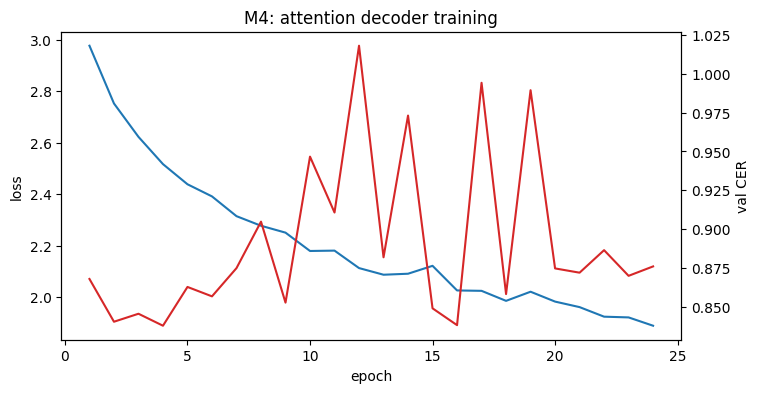

In [10]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history["epoch"], history["train_loss"], label="train CE loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax2 = ax1.twinx(); ax2.plot(history["epoch"], history["CER"], color="tab:red"); ax2.set_ylabel("val CER")
plt.title("M4: attention decoder training"); plt.show()

## 7. Test evaluation + seen/unseen (same protocol as M0/M2)

In [11]:
ck = torch.load(CFG.ckpt_dir / "best.pt", map_location="cpu")
model.load_state_dict(ck["model"]); model.to(DEVICE)
tm, preds, refs, files = evaluate(model, test_dl)
print("M4 — test (overall):", {k: round(v, 4) if isinstance(v, float) else v for k, v in tm.items()})

test_meta = pd.read_csv(CFG.data_root / CFG.test_csv)
seen_map = dict(zip(test_meta[CFG.img_col].astype(str), test_meta["seen_in_train"]))
groups = {"seen": ([], []), "unseen": ([], [])}
for p, r, f in zip(preds, refs, files):
    k = "seen" if seen_map.get(f, False) else "unseen"
    groups[k][0].append(p); groups[k][1].append(r)
print("seen/unseen:")
for k, (P, R) in groups.items():
    if R:
        m = corpus_metrics(P, R)
        print(f"  {k:6s} (n={m['n']:3d}): CER {m['CER']:.4f} | EM {m['ExactMatch']:.4f}")

errors = [(r, p, edit_distance(p, r)) for p, r in zip(preds, refs) if p != r]
errors.sort(key=lambda e: -e[2])
pd.DataFrame(errors, columns=["reference", "prediction", "edit_distance"]).to_csv(
    CFG.ckpt_dir / "m4_errors.csv", index=False)
print(f"\n{len(errors)} errors / {len(refs)} samples")

M4 — test (overall): {'CER': 0.8458, 'ExactMatch': 0.0, 'WER': 1.0, 'n': 791}
seen/unseen:
  seen   (n=615): CER 0.8363 | EM 0.0000
  unseen (n=176): CER 0.8751 | EM 0.0000

791 errors / 791 samples


## 8. For the comparison
Add M4's overall + seen/unseen EM to the results table (Notebook 06). M4 can ALSO be paired
with the lexicon (apply lexicon_decode to M4's predictions) — if M4's raw output is better
than M0's, the lexicon on top of M4 may become the new champion. Note honestly whether the
attention decoder beat, matched, or underperformed the CTC baseline, and why.